<div style="background:linear-gradient(135deg,#3b0764 0%,#7e22ce 55%,#a855f7 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#e9d5ff;font-weight:700;text-transform:uppercase">Chapter 89 · Correlation &amp; Association</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Covariance 🔗</div>
  <div style="font-size:15px;color:#faf5ff;max-width:740px;line-height:1.6">Covariance is the first measure of how two variables move together: its sign tells the direction. But its magnitude depends on units, which is exactly why we standardize it into correlation. We build the intuition visually and apply it to real marketing data.</div>
  <div style="margin-top:16px;font-size:13px;color:#e9d5ff">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
PUR="#9333ea"; DEEP="#7e22ce"; LIGHT="#c084fc"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(89)

<div style="background:#faf5ff;border-left:5px solid #9333ea;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7e22ce;letter-spacing:1px">DEMO 1 · WHAT COVARIANCE MEASURES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The direction two variables move together</div>
<div style="color:#4a5578;margin-top:6px">Covariance is positive when two variables tend to rise together, negative when one rises as the other falls, and near zero when there is no linear tendency. The SIGN is what matters; we visualize all three.</div>
</div>

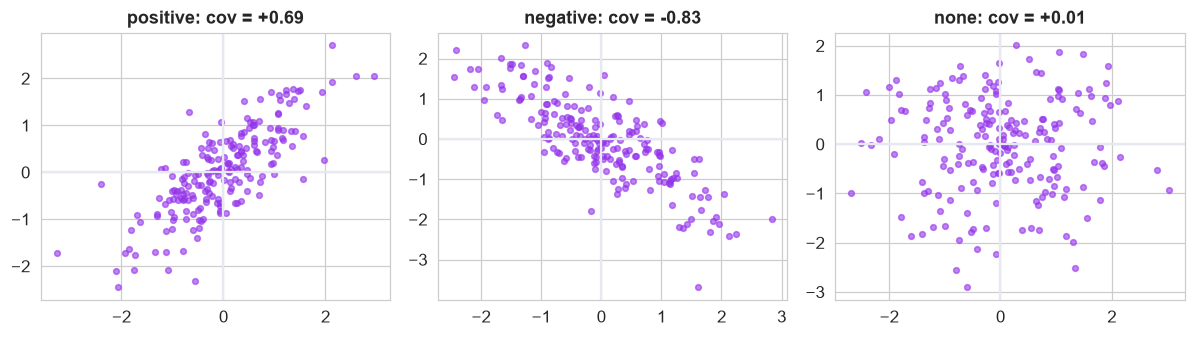

In [2]:
def make(rho, n=200):
    x=rng.normal(0,1,n); y=rho*x+np.sqrt(max(1-rho**2,0))*rng.normal(0,1,n); return x,y
fig,ax=plt.subplots(1,3,figsize=(11,3.2))
for a,(rho,lab) in zip(ax,[(0.8,"positive"),(-0.8,"negative"),(0.0,"none")]):
    x,y=make(rho); a.scatter(x,y,s=14,color=PUR,alpha=0.6)
    a.set_title(f"{lab}: cov = {np.cov(x,y)[0,1]:+.2f}"); a.axhline(0,color=GRID); a.axvline(0,color=GRID)
plt.tight_layout(); plt.show()

A positive covariance slopes up, a negative one slopes down, and an uncorrelated cloud sits near zero. Covariance turns "do these move together?" into a single signed number. <code>np.cov(x, y)</code> returns the 2x2 covariance matrix; the off-diagonal is the covariance.

<div style="background:#faf5ff;border-left:5px solid #9333ea;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7e22ce;letter-spacing:1px">DEMO 2 · THE FORMULA, AND THE QUADRANT INTUITION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Average of the products of deviations</div>
<div style="color:#4a5578;margin-top:6px">Covariance is the mean of (x - x-bar)(y - y-bar). Points in the upper-right and lower-left quadrants (both above or both below their means) contribute POSITIVE products; the other two quadrants contribute negative. The balance is the covariance.</div>
</div>

covariance (formula) = mean of (x-xbar)(y-ybar) = 0.529
covariance (numpy)   = 0.529   (ddof=0 matches the population mean)


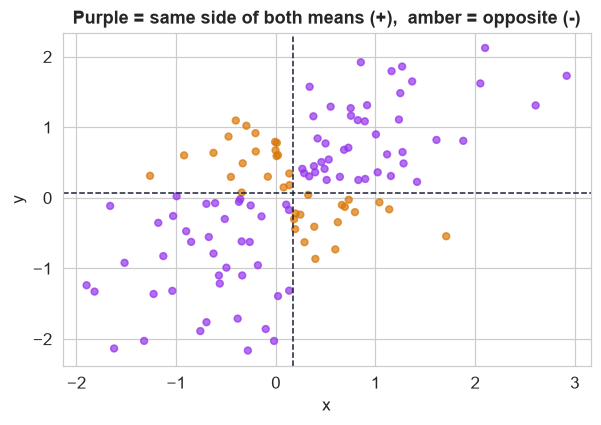

In [3]:
x,y=make(0.7, 120); xb,yb=x.mean(),y.mean()
prod=(x-xb)*(y-yb)
print(f"covariance (formula) = mean of (x-xbar)(y-ybar) = {prod.mean():.3f}")
print(f"covariance (numpy)   = {np.cov(x,y,ddof=0)[0,1]:.3f}   (ddof=0 matches the population mean)")
fig,ax=plt.subplots(figsize=(5.6,4))
ax.scatter(x,y,c=np.where(prod>0,PUR,AMBER),s=20,alpha=0.7)
ax.axvline(xb,color=INK,lw=1,ls="--"); ax.axhline(yb,color=INK,lw=1,ls="--")
ax.set_title("Purple = same side of both means (+),  amber = opposite (-)")
ax.set_xlabel("x"); ax.set_ylabel("y"); plt.tight_layout(); plt.show()

Most points are purple (same side of both means), so the positive products win and the covariance is positive. This is the whole mechanism: covariance counts how often, and how strongly, two variables deviate from their means in the same direction.

<div style="background:#faf5ff;border-left:5px solid #9333ea;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7e22ce;letter-spacing:1px">DEMO 3 · COVARIANCE vs CORRELATION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Covariance depends on units; correlation does not</div>
<div style="color:#4a5578;margin-top:6px">Covariance has units of x times y, so its MAGNITUDE is uninterpretable, change the units and the number changes, even though the relationship is identical. Dividing by the two standard deviations gives CORRELATION, a unitless number in [-1, 1].</div>
</div>

In [4]:
x,y=make(0.75, 300)
print(f"cov(x, y)            = {np.cov(x,y)[0,1]:.3f}")
print(f"cov(x, 1000*y)       = {np.cov(x,1000*y)[0,1]:.1f}   <- 1000x bigger, same relationship!")
corr = np.cov(x,y)[0,1] / (x.std(ddof=1)*y.std(ddof=1))
print(f"correlation = cov / (sx*sy) = {corr:.3f}")
print(f"corr(x, 1000*y)             = {np.corrcoef(x,1000*y)[0,1]:.3f}   <- unchanged (unitless)")

cov(x, y)            = 0.697
cov(x, 1000*y)       = 697.3   <- 1000x bigger, same relationship!
correlation = cov / (sx*sy) = 0.754
corr(x, 1000*y)             = 0.754   <- unchanged (unitless)


Scaling y by 1000 multiplies the covariance by 1000 but leaves the correlation untouched. That is why covariance answers "which direction?" but correlation (Chapter 90) answers "how strongly?" on a comparable scale.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · AD SPEND & SALES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A covariance matrix, then a correlation heatmap</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A marketing team has 160 campaigns with spend, reach, visits, and sales (`ch89_ad_sales.xlsx`). We explore first, then compute the covariance matrix (big, unit-dependent numbers) and the correlation matrix (a readable heatmap).

shape: (160, 6) | missing: 0
                 mean      std      min       max
ad_spend       4880.0   2392.0   1038.0    8993.0
impressions  152240.0  74985.0  23951.0  297674.0
web_visits     2090.0   1021.0     26.0    3973.0
sales         27327.0  12877.0    200.0   51505.0


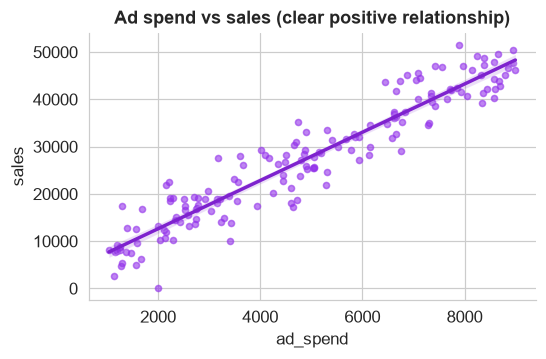

In [5]:
try:    d = pd.read_excel("../../data/ch89_ad_sales.xlsx", sheet_name="Campaigns")
except FileNotFoundError: d = pd.read_excel(BASE+"ch89_ad_sales.xlsx", sheet_name="Campaigns")
num = d[["ad_spend","impressions","web_visits","sales"]]
# EXPLORE FIRST: shape, missing, summary, and a quick scatter of spend vs sales
print("shape:", d.shape, "| missing:", d.isna().sum().sum())
print(num.describe().round(0).T[["mean","std","min","max"]])
sns.lmplot(data=d, x="ad_spend", y="sales", height=3.4, aspect=1.5, scatter_kws=dict(s=16,color=PUR,alpha=0.6), line_kws=dict(color=DEEP))
plt.title("Ad spend vs sales (clear positive relationship)"); plt.tight_layout(); plt.show()

COVARIANCE matrix (units = product of the two columns -> huge, hard to read):
                ad_spend   impressions  web_visits        sales
ad_spend       5719734.0  1.768545e+08   2361710.0   29191117.0
impressions  176854468.0  5.622789e+09  73110416.0  898461771.0
web_visits     2361710.0  7.311042e+07   1042396.0   12001607.0
sales         29191117.0  8.984618e+08  12001607.0  165827662.0

cov(ad_spend, sales) = 29,191,117  (a meaningless magnitude on its own)

CORRELATION matrix (unitless, -1..1 -> readable):
             ad_spend  impressions  web_visits  sales
ad_spend         1.00         0.99        0.97   0.95
impressions      0.99         1.00        0.95   0.93
web_visits       0.97         0.95        1.00   0.91
sales            0.95         0.93        0.91   1.00


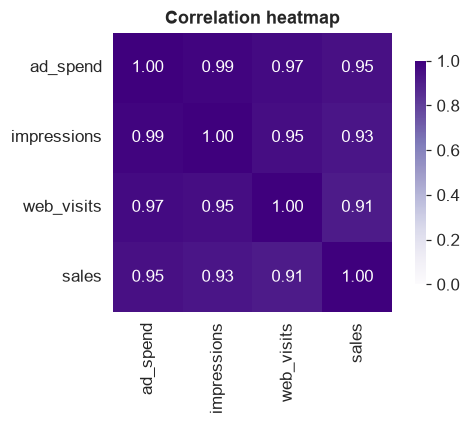

In [6]:
print("COVARIANCE matrix (units = product of the two columns -> huge, hard to read):")
print(num.cov().round(0))
print(f"\ncov(ad_spend, sales) = {num.ad_spend.cov(num.sales):,.0f}  (a meaningless magnitude on its own)")
print("\nCORRELATION matrix (unitless, -1..1 -> readable):")
print(num.corr().round(2))
fig,ax=plt.subplots(figsize=(5.2,4))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="Purples", vmin=0, vmax=1, square=True, ax=ax, cbar_kws=dict(shrink=0.8))
ax.set_title("Correlation heatmap"); plt.tight_layout(); plt.show()

The covariance between ad spend and sales is about <strong>29 million</strong> (dollars times dollars), a number you cannot interpret on its own. Standardized, that same relationship is a correlation of <strong>0.95</strong>, instantly readable as "very strong and positive." All four marketing metrics move together, which is why the next chapter focuses on correlation, the standardized cousin built for comparing relationships.

<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Covariance</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">Covariance is the mean of the products of deviations: positive when variables move together, negative when they move oppositely, near zero when unrelated. Its SIGN is meaningful but its MAGNITUDE depends on units, so we standardize by dividing by the two SDs to get correlation in [-1, 1]. On real ad data, cov(spend, sales) &#8776; 29 million dollars&#178; is unreadable, while the correlation 0.95 says "very strong" at a glance. Next: correlation coefficients in depth.</div></div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>